<a href="https://colab.research.google.com/github/wesnasimone/IA025_Introducao_Aprendizado_Profundo/blob/main/Exerc%C3%ADcio_Modelo_de_Linguagem_(Bengio_2003)_MLP_%2B_Embeddings__Wesna_225843.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Enunciado do Exercício: Modelo de Linguagem (Bengio 2003) - MLP + Embeddings

Neste exercício, o objetivo é implementar e treinar uma rede neural similar a do (Bengio et al, 2003) para prever a próxima palavra de um texto, data as palavras anteriores como entrada. Esta tarefa é chamada de "Modelagem da Linguagem".

O modelo deve ser simplificado, utilizando-se de: Embedding e duas camadas: uma não linear e outra de saída com tamanho do vocabulário. Avalie a perplexidade do modelo, e implemente uma função que permite a geração de texto baseada num contexto de, por exemplo, 5 palavras.

* Não é permitido usar nn.Embedding (use a forma mostrada em aula)
* Existem várias formas de criar os contextos e implementar o Dataset. Isso pode afetar a perplexidade!
* Verifique se melhorar a tokenização melhora a performance. Atenção para o tratamento de unknowns!
* Verifique o efeito de aumentar o contexto e parâmetros da rede.


## Classe do dataset

A Classe Dataset é um dos aspectos mais trabalhosos do desenvolvimento de modelos com Deep Learning. Crie uma classe Dataset do PyTorch para este problema utilizando os dados de Machado de Assis mostrados na aula. Lembre-se de documentar e testar utilizando-se de asserts. Explique sua lógica de forma concisa com comentários.

Existem várias formas de criar o contexto e tratar questões de tokenização e palavras desconhecidas.

In [ ]:
import os
import re
import torch
from collections import Counter
from torch.utils.data import DataLoader
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import trange
import matplotlib.pyplot as plt
import random
from tqdm import tqdm

In [ ]:
def count_words(text):
    # TODO: escreva o código aqui.
    #passo 1: quebrar as palavras
    regex = r"\w+|[^\w\s]"           #pega todas as palavras mas desconsidera espaços ou numeros (isso faz com que pontuação seja identificada)

    #passo 2: conta o numero de palavras ou pontuação
    word_counts = Counter()
    for texts in text:
        text_modificado = texts.lower()   #transforma texto em minusculas
        resultado = re.findall(regex, text_modificado)
        word_counts.update(resultado)

    return word_counts

In [ ]:
def tokens_to_ids(text, vocabulary):
    # TODO: escreva o código aqui.
    id = []
    for chave in text:
      text_modificado = chave.lower()   #transforma texto em minusculas
      if text_modificado in vocabulary:
        id.append(vocabulary[text_modificado])
      else:
        id.append(0)
    return id

In [ ]:
#seleciona somente sentenças que tenha pelo menos o valor de conxt_size + 1
def filter_data(data, context_size):
    data_filtrado = []

    for texto in data:
        tokens = re.findall(r"\w+|[^\w\s]", texto)

        if len(tokens) >= context_size + 1:
            data_filtrado.append(texto)

    return data_filtrado

In [ ]:
class MyDataset(torch.utils.data.Dataset):

    def __init__(self, caminho_arquivo, tam_vocab, context_size, train=True, split_train=0.8):
        super().__init__()

        self.caminho_arquivo = caminho_arquivo
        self.train = train
        self.split_train = split_train
        self.tam_vocab = tam_vocab
        self.context_size = context_size

        #baixando o dataset machado de assis
        if os.path.exists(caminho_arquivo):
          print('O arquivo está baixado e disponível!')
        else:
          print('O arquivo ainda não foi baixado ou não existe.')
          print('Baixando...')
          !git clone https://github.com/ethelbeluzzi/projetomachado
          print('Dataset Baixado!')

        #caminho do dataset com o arquivo de dados
        DATA_PATH = os.path.join("projetomachado", "textonormalizado1000.txt")

        # Abrir arquivo textual e ler os dados originais
        with open(DATA_PATH, "r") as data_file:
            self.data_text = [line.strip().lower() for line in data_file] #já desconsidera o \n entre as frases

        #divisão treino e validação
        data = self.data_text.copy()
        random.seed(42)
        random.shuffle(data)
        limit = int(self.split_train*len(data))
        train_data1 = data[:limit]
        val_data1 = data[limit:]

        #criação de vocabulario com base no conjunto de treino
        word_counts = count_words(train_data1)
        most_frequent_words = [word for word, count in word_counts.most_common(self.tam_vocab)]
        self.vocab = {word: i for i, word in enumerate(most_frequent_words, 1)} # --> vocabulario começa em 1 para reservar zero para as palavras desconhecidas

        #filtra o conjunto de treino e validação para ter o tamanho de context_size
        self.train_data = filter_data(train_data1, self.context_size)
        self.val_data = filter_data(val_data1, self.context_size)

    def __len__(self):
        if self.train:
            return len(self.train_data)
        else:
            return len(self.val_data)

    def __getitem__(self, idx):

        #PASSO I: tokenização
        if self.train:
          data = self.train_data
        else:
          data = self.val_data

        texto = re.findall(r"\w+|[^\w\s]", data[idx]) #quebra a frase em palavras e pontuação
        token = texto[:self.context_size]             #separa tokens
        label = texto[self.context_size]              #separa próxima palavra

        #transforma tokens e label em indices --> palavras desconhecidas do vocabulario é atribuido indice zero
        id_token = torch.tensor(tokens_to_ids(token, self.vocab))
        id_label = torch.tensor(self.vocab.get(label.lower(), 0)) #como é uma palavra já da para tirar direto do vocabulario


        texto_token = " ".join(token) #ajuda a vizualizar o texto

        return texto_token, label, id_token, id_label

In [ ]:
"""SUGESTÃO: divida o dataset em validação/treino com um proporção de 20/80 %. OBS, caso use suffle, use uma semente (random_state) para o embaralhamento ser o mesmo ao re-rodar o notebook"""

'SUGESTÃO: divida o dataset em validação/treino com um proporção de 20/80 %. OBS, caso use suffle, use uma semente (random_state) para o embaralhamento ser o mesmo ao re-rodar o notebook'

In [ ]:
"""TODO: implemente a classe do dataset e teste, visualizando amostras"""

context_size = 5 # 5 palavras de entrada (pode mudar). O target é a próxima palavra
caminho_arquivo = "projetomachado"
tam_vocab = 20000
train_data = MyDataset(caminho_arquivo, tam_vocab, context_size)
val_data = MyDataset(caminho_arquivo, tam_vocab, context_size, train=False)

O arquivo ainda não foi baixado ou não existe.
Baixando...
Cloning into 'projetomachado'...
remote: Enumerating objects: 65, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 65 (delta 24), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (65/65), 7.21 MiB | 3.21 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Dataset Baixado!
O arquivo está baixado e disponível!


In [ ]:
#Vocabulário como 20000 palavras
train_data.vocab

{',': 1,
 '.': 2,
 'a': 3,
 'que': 4,
 'de': 5,
 'e': 6,
 'o': 7,
 'não': 8,
 ';': 9,
 'um': 10,
 'do': 11,
 'da': 12,
 'os': 13,
 'é': 14,
 'com': 15,
 'uma': 16,
 'se': 17,
 'em': 18,
 'para': 19,
 'mas': 20,
 'as': 21,
 'era': 22,
 '?': 23,
 'ao': 24,
 'por': 25,
 'no': 26,
 'à': 27,
 'mais': 28,
 '!': 29,
 'na': 30,
 'ele': 31,
 'eu': 32,
 'como': 33,
 'lhe': 34,
 'me': 35,
 'ou': 36,
 'foi': 37,
 'dos': 38,
 ':': 39,
 'ela': 40,
 'nem': 41,
 'das': 42,
 'quando': 43,
 'sem': 44,
 'disse': 45,
 'casa': 46,
 'já': 47,
 'depois': 48,
 'há': 49,
 'tudo': 50,
 'ser': 51,
 'tinha': 52,
 'meu': 53,
 'ainda': 54,
 'só': 55,
 'nada': 56,
 'olhos': 57,
 'tempo': 58,
 'muito': 59,
 'd': 60,
 'minha': 61,
 'outro': 62,
 'outra': 63,
 'também': 64,
 'mesmo': 65,
 'dia': 66,
 'tão': 67,
 'estava': 68,
 'seu': 69,
 'até': 70,
 'esta': 71,
 'este': 72,
 'porque': 73,
 'vez': 74,
 'nos': 75,
 'assim': 76,
 'sua': 77,
 'pouco': 78,
 'bem': 79,
 'agora': 80,
 'vida': 81,
 'às': 82,
 'homem': 83,
 'e

### Inicialização de DataLoaders
Os DataLoaders do PyTorch cuidam da criação do batch de forma eficiente e com possibildade de paralelismo. Sempre visualize exemplos do DataLoader também para verificar que o batch está sendo criado da forma esperada. Grande parte dos erros ocorrem na definição do Dataset e do Dataloader.

In [ ]:
batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
token, label, id_token, id_label = next(iter(train_loader))

#Treino
elem = 0
print(f'Token Shape: {id_token.shape}')
print(f'Label Shape: {id_label.shape}')
print('')
print(f'Token: {token[elem]}\nid token: {id_token[elem]}')
print(f'Label: {label[elem]}\nid label : {id_label[elem]}')

Token Shape: torch.Size([32, 5])
Label Shape: torch.Size([32])

Token: tarde . afirmou o principal
id token: tensor([ 212,    2, 4754,    7,  921])
Label: ,
id label : 1


In [ ]:
token1, label1, id_token1, id_label1 = next(iter(val_loader))

#Validação
elem = 0
print(f'Token Shape: {id_token1.shape}')
print(f'Label Shape: {id_label1.shape}')
print('')
print(f'Token: {token1[elem]}\nid token: {id_token1[elem]}')
print(f'Label: {label1[elem]}\nid label : {id_label1[elem]}')

Token Shape: torch.Size([32, 5])
Label Shape: torch.Size([32])

Token: peruana era bela e alta
id token: tensor([   0,   22,  439,    6, 1068])
Label: ,
id label : 1


## Model
Crie uma classe de Modelo herdando de torch.nn.Module. Um nn.Module deve definir o que acontece no "forward", ou seja, o que é feito com o dado (geralmente o batch) fornecido para a rede.

In [ ]:
#model --> https://medium.com/@dahami/a-neural-probabilistic-language-model-breaking-down-bengios-approach-4bf793a84426

In [ ]:
import torch.nn as nn

class LanguageModel(torch.nn.Module):
    """TODO: implementar o modelo de linguagem"""

    def __init__(self, vocab_size, embedding_dim, context_size, hidden_dim):
        super().__init__()

        # Word embeddings (Embedding matrix)
        #utiliza-se vocab_size + 1 pois é necessário considerar uma posição para as palavras desconhecidas que não estão em vocab
        self.embeddings = nn.Parameter(torch.randn((vocab_size + 1, embedding_dim), requires_grad=True)*0.1)

        # Hidden layer
        self.linear1 = nn.Linear(context_size * embedding_dim, hidden_dim)

        # Activation function
        self.tanh = nn.Tanh()

        # Output layer
        self.linear2 = nn.Linear(hidden_dim, vocab_size+1)

        #dropout
        self.dropout = nn.Dropout(0.2)



    def forward(self, inputs):

        # Flatten embeddings
        embeds = self.embeddings[inputs].view(inputs.size(0), -1)

        # First linear transformation
        out = self.linear1(embeds)

        # Apply tanh activation
        out = self.tanh(out)

        #regularização --> colocar isso melhorou um pouco o overffiting
        out = self.dropout(out)

        # Second linear transformation
        out = self.linear2(out)

        return out

### Teste do modelo
É essencial testar o forward do modelo antes de tentar treinar, muitos erros podem ser pegos neste teste rápido. Use uma amostra do DataLoader para testar se as saídas são o esperado. Calcule a perplexidade do modelo sem treinar, e verifique se é o esperado.

In [ ]:
vocab_size = tam_vocab #20000
embedding_dim = 50
context_size = context_size
hidden_dim = 64

model = LanguageModel(vocab_size, embedding_dim, context_size, hidden_dim)

In [ ]:
#parametros da rede
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Parâmetros treináveis: {trainable_params}")
print(f"Total de parâmetros: {total_params}")

Parâmetros treináveis: 2316179
Total de parâmetros: 2316179


In [ ]:
#tamanho da matriz C
model.embeddings.shape

torch.Size([20001, 50])

In [ ]:
sample = next(iter(train_loader))
input = sample[2]
target = sample[3]

In [ ]:
input.shape

torch.Size([32, 5])

In [ ]:
output = model(input)

In [ ]:
output.argmax(dim=1)

tensor([13970,  7106, 10268,   870,  8976, 18263, 16488,  5347,  9202, 16951,
         4829,   492, 14605, 10459, 10437,  7864, 17231,  9023, 12086,  6829,
        19354,  6752,  6134,  8716,   870,  7106,  7072,  8189,  6638,  2338,
          245,  8901])

In [ ]:
target

tensor([ 5056,    16,  1291,   309,   505,     3,    17,  1170, 12718,     9,
            2,     2,    26,    13,    11,    20,    52, 11727, 11022,     3,
         1859,   197,     1,     0,  4946,     3,     5,     7,     1,   244,
          218,    54])

In [ ]:
# TODO perplexidade sem treino?

def perplexidade(probabilidade):

  expoente = -torch.mean(torch.log(probabilidade))
  pp = torch.exp(expoente)

  return pp

a = 1/vocab_size
tensor = torch.tensor(a)
pp_sem_treino = perplexidade(tensor)
print(f"Perplexidade sem treino: {pp_sem_treino}")


Perplexidade sem treino: 19999.9921875


## Training
Finalmente, implemente o loop de treino, onde os dados são fornecidos ao modelo, e os otimizadores otimizam os pesos do modelo em uma tentativa de minimizar a função de perda.

Procure organizar o loop de treino em múltiplas funções em vez de um código monolítico, para facilitar a re-utilização de código no futuro.

Procure informar o resultado da loss tanto em treino quanto em validação. Plote um gráfico da loss e perplexidade em cada época de treino e validação.

In [ ]:
class MyCrossEntropyLoss():
    """
    TODO Implemente a classe que faz softmax e entropia cruzada, sem usar as funções prontas do PyTorch (nn ou functional),
    somente operações sobre tensores.
    """
    def __init__(self, num_classes):
        self.num_classes = num_classes

    def __call__(self, logits, labels):
      #passo1: tranformar labels em one_hot
      label_one_hot_encoded = F.one_hot(labels, self.num_classes)

      # Subtrair o maior logit para evitar overflow
      logits_stable = logits - torch.max(logits, dim=1, keepdim=True).values

      #passo2: calcular probabilidades (softmax)
      exponencial = torch.exp(logits_stable)
      probabilidade = exponencial/torch.sum(exponencial, dim=1, keepdim=True)
      probabilidade = torch.clamp(probabilidade, min=1e-8)

      #passo3: calcular a entropia cruzada --> loss
      loss = -(torch.sum(label_one_hot_encoded*torch.log(probabilidade))) / logits_stable.shape[0]

      return loss, probabilidade

In [ ]:
# Verifica se há uma GPU disponível e define o dispositivo para GPU se possível, caso contrário, usa a CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
###### Parametros ########
epochs = 10
lr = 0.001
criterion = MyCrossEntropyLoss(tam_vocab + 1)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

model.to(device)

In [ ]:
loss_treino = []
loss_valid = []
pp_valid_epoca = []
probabilidades = []

best_val_loss = float("inf")
best_model_state = None

"""TODO: Implemente o loop de treinamento."""
for epoca in range(epochs):
  loss_batch_treino = 0
  loss_batch_valid = 0
  pp_soma = 0

  ################### LOOP TREINO #####################
  model.train()
  with trange(len(train_loader), desc='Loop Treino') as progress_bar:
    for batch_idx, batch in zip(progress_bar, train_loader):
      _, _, x, label = batch
      x = x.to(device)
      label = label.to(device)

      #PASSO 1: forward
      y = model(x)

      loss, prob = criterion(y, label)

      #pega somente as probabilidades referentes ao batch especifico
      probabilidade = prob[torch.arange(label.size(0), device=label.device), label]

      ppx_treino = perplexidade(probabilidade)
      loss_batch_treino += loss.item()
      progress_bar.set_postfix(desc=(f"[Epoca {epoca + 1}] Loss: {loss.item():.4f} PP: {ppx_treino:.4f}"))


      #PASSO2: backpropagation
      loss.backward()
      optimizer.step()      #atualiza os pesos do modelo usando o otimizador
      optimizer.zero_grad() #reseta os gradientes

    loss_epoca = loss_batch_treino/len(train_loader) #loss por epoca
    loss_treino.append(loss_epoca)


  ###################### LOOP VALIDAÇÃO ######################
  #não atualiza mais nada
  with trange(len(val_loader), desc='Loop Valid') as progress_bar:
    with torch.no_grad():
      model.eval()
      probabilidades = []
      for batch_idx, batch in zip(progress_bar, val_loader):
        _, _, x, label = batch
        x = x.to(device)
        label = label.to(device)

        #PASSO 1: forward
        y = model(x)

        loss, prob = criterion(y, label)

        #pega somente as probabilidades referentes ao batch especifico
        probabilidade = prob[torch.arange(label.size(0), device=label.device), label]

        #acumular probebilidade do batch
        probabilidades.append(probabilidade)

        ppx_val = perplexidade(probabilidade)
        loss_batch_valid += loss.item()
        pp_soma += ppx_val.item()
        progress_bar.set_postfix(desc=(f"[Epoca {epoca + 1}] Loss: {loss.item():.4f} PP: {ppx_val:.4f}"))


      loss_epoca_valid = loss_batch_valid/len(val_loader) #loss por epoca

      #salva melhor epoca
      if loss_epoca_valid < best_val_loss:
        best_val_loss = loss_epoca_valid

        best_model_state = {
          key: value.cpu().clone()
          for key, value in model.state_dict().items()
        }

        print(f"Novo melhor modelo na época {epoca}")

      loss_valid.append(loss_epoca_valid)

      #perplexidade da época
      probabilidades_epoca = torch.cat(probabilidades)
      pp_final = perplexidade(probabilidades_epoca)
      pp_valid_epoca.append(pp_final)

Loop Valid: 100%|██████████| 1578/1578 [00:04<00:00, 320.24it/s, desc=[Epoca 1] Loss: 4.7526 PP: 115.8833]


Novo melhor modelo na época 0


Loop Valid: 100%|██████████| 1578/1578 [00:04<00:00, 319.05it/s, desc=[Epoca 2] Loss: 4.8015 PP: 121.6935]


Novo melhor modelo na época 1


Loop Valid: 100%|██████████| 1578/1578 [00:05<00:00, 297.12it/s, desc=[Epoca 3] Loss: 4.7990 PP: 121.3914]


...

Loop Valid: 100%|██████████| 1578/1578 [00:05<00:00, 297.73it/s, desc=[Epoca 6] Loss: 4.7930 PP: 120.6684]


Novo melhor modelo na época 5


Loop Valid: 100%|██████████| 1578/1578 [00:04<00:00, 316.17it/s, desc=[Epoca 7] Loss: 4.8231 PP: 124.3484]


Novo melhor modelo na época 6


Loop Valid: 100%|██████████| 1578/1578 [00:05<00:00, 306.88it/s, desc=[Epoca 10] Loss: 4.7384 PP: 114.2532]


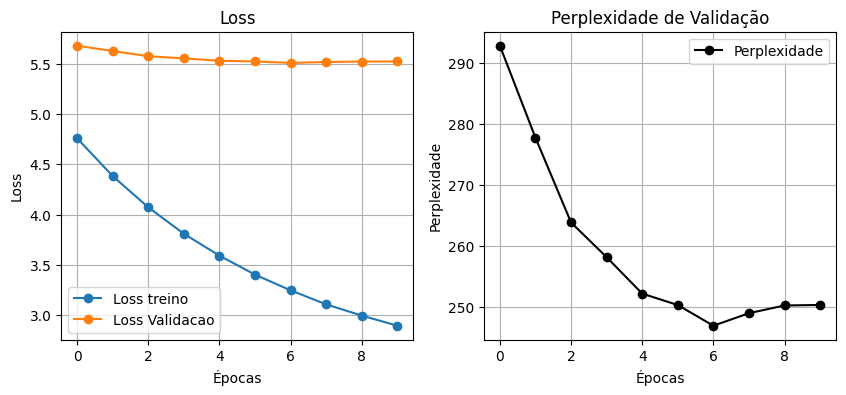

In [ ]:
# TODO
##### Graficos ######
plt.figure(figsize=(10, 4))

#Loss treino x validação
plt.subplot(1, 2, 1)
plt.plot(loss_treino, 'o-', label=f'Loss treino')
plt.plot(loss_valid, 'o-', label=f'Loss Validacao')
plt.title("Loss")
plt.ylabel('Loss')
plt.xlabel('Épocas')
plt.legend()
plt.grid()

#Métricas
plt.subplot(1, 2, 2)
lista_normal = [t.item() for t in pp_valid_epoca]
plt.plot(lista_normal, 'o-', color='black', label=f'Perplexidade')
plt.title("Perplexidade de Validação")
plt.ylabel('Perplexidade')
plt.xlabel('Épocas')
plt.legend()
plt.grid()

plt.show()

## Avaliação
Calcule a perplexidade utilizando todo o dataset de validação.

In [ ]:
""" TODO: calcule a perplexidade final no dataset de validação """
val_loader1 = DataLoader(val_data, batch_size=1, shuffle=False)
model.load_state_dict(best_model_state) #melhor modelo --> epoca 6
model.to(device)

pp_valid_epoca1 = []
probabilidades1 = []

###################### LOOP VALIDAÇÃO ######################

with torch.no_grad():
  model.eval()
  for batch in tqdm(val_loader1):
    _, _, x, label = batch
    x = x.to(device)
    label = label.to(device)

    #PASSO 1: forward
    y = model(x)

    loss, prob = criterion(y, label)

    #pega somente as probabilidades referentes ao batch especifico
    probabilidade = prob[torch.arange(label.size(0), device=label.device), label]
    probabilidades1.append(probabilidade)


  # perplexidade da época
  probabilidades1 = torch.cat(probabilidades1)
  pp_final1 = perplexidade(probabilidades1)

  pp_valid_epoca1.append(pp_final1)

100%|██████████| 50487/50487 [00:35<00:00, 1438.81it/s]


In [ ]:
print(f'Perplexidade Validação pós Treino: {pp_valid_epoca1}')

Perplexidade Validação pós Treino: [tensor(246.9152, device='cuda:0')]


## Exemplo de uso
Como um modelo de linguagem pode gerar um texto? Pense como uma "janela deslizante", onde o contexto é sempre as palavras anteriores. Produza textos para avaliar o modelo de forma qualitativa, tente fazer um "chatbot rudimentar".

In [ ]:
# Inverte o dicionário: vira {valor: chave}
vocabulario = train_data.vocab
vocab_invertido = {v: k for k, v in vocabulario.items()}
vocab_invertido

{1: ',',
 2: '.',
 3: 'a',
 4: 'que',
 5: 'de',
 6: 'e',
 7: 'o',
 8: 'não',
 9: ';',
 10: 'um',
 11: 'do',
 12: 'da',
 13: 'os',
 14: 'é',
 15: 'com',
 16: 'uma',
 17: 'se',
 18: 'em',
 19: 'para',
 20: 'mas',
 21: 'as',
 22: 'era',
 23: '?',
 24: 'ao',
 25: 'por',
 26: 'no',
 27: 'à',
 28: 'mais',
 29: '!',
 30: 'na',
 31: 'ele',
 32: 'eu',
 33: 'como',
 34: 'lhe',
 35: 'me',
 36: 'ou',
 37: 'foi',
 38: 'dos',
 39: ':',
 40: 'ela',
 41: 'nem',
 42: 'das',
 43: 'quando',
 44: 'sem',
 45: 'disse',
 46: 'casa',
 47: 'já',
 48: 'depois',
 49: 'há',
 50: 'tudo',
 51: 'ser',
 52: 'tinha',
 53: 'meu',
 54: 'ainda',
 55: 'só',
 56: 'nada',
 57: 'olhos',
 58: 'tempo',
 59: 'muito',
 60: 'd',
 61: 'minha',
 62: 'outro',
 63: 'outra',
 64: 'também',
 65: 'mesmo',
 66: 'dia',
 67: 'tão',
 68: 'estava',
 69: 'seu',
 70: 'até',
 71: 'esta',
 72: 'este',
 73: 'porque',
 74: 'vez',
 75: 'nos',
 76: 'assim',
 77: 'sua',
 78: 'pouco',
 79: 'bem',
 80: 'agora',
 81: 'vida',
 82: 'às',
 83: 'homem',
 84

In [ ]:
def generate_text(model, vocab, vocab_invertido, text, max_length, context):
    """TODO: implemente a função para gerar texto até atingir o max_length

    model: modelo treinado com mesmo tamanho de context
    vocab: vocabulário baseado no conjunto de treino (chave --> indice)
    vocab_invertida: é identico ao vocab mas o indice vira chave e a chave vira indice (indice --> chave)
    text: é o texto para iniciar o contexto
    max_length: quantidade de palavras geradas
    context: tamanho do contexto

    """

    count = 0
    texto_gerado = []

    #Passo I: quebrar texto em palavras ou pontuação e selecionar a janela de contexto
    texto = re.findall(r"\w+|[^\w\s]", text.lower()) #quebra a frase em palavras e pontuação
    contexto_atual = texto[:context]
    texto_gerado = contexto_atual.copy()

    while count < max_length:

      #Passo II: transformar em token
      token = torch.tensor(tokens_to_ids(contexto_atual, vocab)).unsqueeze(0)

      #Passo IV: predizer
      y = model(token).argmax(dim=1).item() # --> preve o indice


      #Passo V: achar a predição no vocabulário
      proxima_palavra = vocab_invertido.get(y, "<desconhecido>") # --> usa o vocabulario invertido para facilitar a busca da palavra
      print(f"{contexto_atual}: {proxima_palavra}")
      texto_gerado.append(proxima_palavra)

      #Passo VI: atualizar o contexto com a palavra gerada
      contexto_atual.append(proxima_palavra)
      contexto_atual = contexto_atual[-context:]
      count = count + 1

    #mostra o texto completo
    texto_final = ' '.join(texto_gerado)
    print('')
    print(f'Gerando texto: {texto_final}')

In [ ]:
text = "No outono as folhas caem"
context = 5
max_length= 10 #quants palavras o modelo vai gerar
generate_text(model, vocabulario, vocab_invertido, text, max_length, context)

['no', 'outono', 'as', 'folhas', 'caem']: do
['outono', 'as', 'folhas', 'caem', 'do']: resto
['as', 'folhas', 'caem', 'do', 'resto']: .
['folhas', 'caem', 'do', 'resto', '.']: que
['caem', 'do', 'resto', '.', 'que']: lhe
['do', 'resto', '.', 'que', 'lhe']: fez
['resto', '.', 'que', 'lhe', 'fez']: ,
['.', 'que', 'lhe', 'fez', ',']: e
['que', 'lhe', 'fez', ',', 'e']: a
['lhe', 'fez', ',', 'e', 'a']: verdade

Gerando texto: no outono as folhas caem do resto . que lhe fez , e a verdade


In [ ]:
text = "A galinha pintadinha e o galo"
context = 5
max_length= 10 #quantas palavras o modelo vai gerar
generate_text(model, vocabulario, vocab_invertido, text, max_length, context)

['a', 'galinha', 'pintadinha', 'e', 'o']: <desconhecido>
['galinha', 'pintadinha', 'e', 'o', '<desconhecido>']: da
['pintadinha', 'e', 'o', '<desconhecido>', 'da']: rua
['e', 'o', '<desconhecido>', 'da', 'rua']: do
['o', '<desconhecido>', 'da', 'rua', 'do']: ouvidor
['<desconhecido>', 'da', 'rua', 'do', 'ouvidor']: ,
['da', 'rua', 'do', 'ouvidor', ',']: ia
['rua', 'do', 'ouvidor', ',', 'ia']: passar
['do', 'ouvidor', ',', 'ia', 'passar']: o
['ouvidor', ',', 'ia', 'passar', 'o']: teatro

Gerando texto: a galinha pintadinha e o <desconhecido> da rua do ouvidor , ia passar o teatro
